In [1]:
import os
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.ticker as plticker

import numpy as np
import pandas as pd
import seaborn as sns
import unittest
from tqdm import tqdm

tc = unittest.TestCase()

sns.set_theme(style="ticks")
sns.set_context("poster", font_scale=1)
sns.set_palette("Set1", 10)
sns.set_style({"font.family": "serif", "font.serif": "Courier New"})

if Path.cwd().name == "workdir":
    pass
elif Path.cwd().name == "proj-jailbreak-sandbox":
    os.chdir("workdir")
elif Path.cwd().name == "core":
    os.chdir("../../workdir")
else:
    print(Path.cwd())
    print(
        "Current directory is not workdir or proj-jailbreak-sandbox. Please check the path."
    )
    exit(1)

print(Path.cwd())
figure_dir_path = Path(
    r"/scratch/gilbreth/hongyu/project/sandbox/2024-Defend-Transferable-Jailbreak-with-Speculative-Inference/figures"
)

/scratch/gilbreth/hongyu/project/sandbox/proj-jailbreak-sandbox/workdir


In [2]:
dataset_name = "RPAB"
intent_number = 50

target_model_name_list = [
    "Meta-Llama-3-70B-Instruct-AWQ",
    "Qwen1.5-72B-Chat-AWQ",
    "Phi-3-medium-128k-instruct",
]
generation_name_list = ["GCG", "AutoDAN"]
dataset_name_list = ["RPAB"]
draft_model_name_list = [
    "opt-125m-AWQ",
    "SmolLM-135M",
    "Qwen2.5-0.5B",
    "Llama-3.2-1B",
    "SmolLM2-135M",
    "SmolLM2-360M",
]
draft_number_list = [1, 5, 10, 15, 20, 25, 30, 35]

In [3]:
def read_pickle(step_6_result_path, generation_name):
    with open(
        step_6_result_path,
        "rb",
    ) as f:
        step_6_pickle_data = pickle.load(f)
        attempts = step_6_pickle_data["attempts"]
        df = pd.DataFrame(attempts)
        df["attempt_id"] = df.index
        df = df.drop(columns=["prompt", "responses"])

        if generation_name == "GCG":
            assert len(df) == 100
        elif generation_name == "AutoDAN":
            assert len(df) == 50
        else:
            raise ValueError(f"generation_name {generation_name} is not supported.")

        return df

In [4]:
step_6_result_list = []

target_model_name_dict = {
    "Meta-Llama-3-70B-Instruct-AWQ": "Llama-3-70B",
    "Qwen1.5-72B-Chat-AWQ": "Qwen1.5-72B",
    "Phi-3-medium-128k-instruct": "Phi-3-medium",
}

intent_index_to_category_mapping = pd.read_pickle(
    "/scratch/gilbreth/hongyu/project/sandbox/AutoDAN/workdir/intent_index_to_category.pkl"
)

for dataset_name in dataset_name_list:
    for target_model_name in tqdm(target_model_name_list):
        for generation_name in generation_name_list:
            for draft_model_name in draft_model_name_list:
                for draft_number in draft_number_list:
                    for intent_index in range(intent_number):
                        with open(
                            Path().cwd()
                            / "step_5_result"
                            / dataset_name
                            / target_model_name
                            / generation_name
                            / "LlamaGuardPromptResponse"
                            / f"{intent_index}.pkl",
                            "rb",
                        ) as f:
                            step_5_pickle_data = pickle.load(f)
                            attempts = step_5_pickle_data["attempts"]
                            step_5_df = pd.DataFrame(attempts)
                            target_model_evaluation = step_5_df["label"]

                        step_6_result_path = (
                            Path().cwd()
                            / "step_6_result"
                            / dataset_name
                            / target_model_name
                            / generation_name
                            / draft_model_name
                            / f"{draft_number}"
                            / f"{intent_index}.pkl"
                        )
                        try:
                            step_6_df = read_pickle(step_6_result_path, generation_name)
                        except FileNotFoundError:
                            print(
                                f"File {step_6_result_path} not found."
                            )
                            continue

                        step_6_df["dataset_name"] = dataset_name
                        step_6_df["target_model_name"] = target_model_name_dict[
                            target_model_name
                        ]
                        step_6_df["generation_name"] = generation_name
                        step_6_df["draft_model_name"] = draft_model_name
                        step_6_df["draft_number"] = draft_number
                        step_6_df["intent_index"] = intent_index
                        step_6_df["category"] = intent_index_to_category_mapping[
                            intent_index
                        ]

                        tc.assertEqual(
                            len(step_6_df),
                            len(step_5_df),
                        )
                        step_6_df["target_model_evaluation"] = target_model_evaluation

                        step_6_result_list.append(step_6_df)

df = pd.concat(step_6_result_list, ignore_index=True)


def generate_transferability_rate(row):
    assert len(row["labels"]) == row["draft_number"]
    transferability_rate = sum(row["labels"]) / row["draft_number"]
    return transferability_rate


df[f"transferability_rate"] = df.apply(generate_transferability_rate, axis=1)
df = df.drop(columns=["labels", "time"])

# v = (
#     len(dataset_name_list)
#     * len(target_model_name_list)
#     * len(draft_model_name_list)
#     * len(draft_number_list)
#     * intent_number
# ) * 150

# tc.assertEqual(len(df), v)

# select the rows where target_model_evaluation is True
df = df[df["target_model_evaluation"] == True]

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [06:01<00:00, 120.47s/it]


In [5]:
original_df = df
original_df.columns

Index(['attempt_id', 'dataset_name', 'target_model_name', 'generation_name',
       'draft_model_name', 'draft_number', 'intent_index', 'category',
       'target_model_evaluation', 'transferability_rate'],
      dtype='object')

In [6]:
df = original_df

assert len(df["dataset_name"].unique()) == 1

df = original_df.drop(
    columns=[
        "dataset_name",
    ]
)

# filter the data from df, where the (generation_name=="GCG" and attempt_id==99) or (generation_name=="AutoDAN" and attempt_id==49)
df = df[
    ((df["generation_name"] == "GCG") & (df["attempt_id"] == 99))
    | ((df["generation_name"] == "AutoDAN") & (df["attempt_id"] == 49))
]

df_gcg = df[df["generation_name"] == "GCG"]
assert len(df_gcg["generation_name"].unique()) == 1
assert len(df_gcg["attempt_id"].unique()) == 1
df_gcg = df_gcg.drop(
    columns=[
        "generation_name",
        "attempt_id",
    ]
)

df_autodan = df[df["generation_name"] == "AutoDAN"]
assert len(df_autodan["generation_name"].unique()) == 1
assert len(df_autodan["attempt_id"].unique()) == 1
df_autodan = df_autodan.drop(
    columns=[
        "generation_name",
        "attempt_id",
    ]
)

In [7]:
def agg_draft_number_and_intent_index(df, draft_number):
    df = df[df["draft_number"] == draft_number]
    assert len(df["draft_number"].unique()) == 1
    df = df.drop(columns=["draft_number"])

    v = (
        df.groupby(["target_model_name", "draft_model_name"])["transferability_rate"]
        .agg(["mean", "max", "std"])
        .reset_index()
    )

    return v


df_gcg_agg = agg_draft_number_and_intent_index(df_gcg, 1)
df_autodan_agg = agg_draft_number_and_intent_index(df_autodan, 1)

In [8]:
import matplotlib.patches as patches


def heatmap(df, values, vmin=None, vmax=None):
    """
    values: "mean", "max", "std"
    """
    df_pivot = df.pivot(
        index="target_model_name", columns="draft_model_name", values=values
    )
    # set the order of the columns to col_order
    col_order = [
        "opt-125m-AWQ",
        "SmolLM-135M",
        "Qwen2.5-0.5B",
        "Llama-3.2-1B",
        "SmolLM2-135M",
        "SmolLM2-360M",
    ]
    df_pivot = df_pivot[col_order]

    row_order = [
        "Llama-3-70B",
        "Phi-3-medium",
        "Qwen1.5-72B",
    ]
    # set the order of the index to row_order
    df_pivot = df_pivot.reindex(row_order)

    ax = sns.heatmap(
        df_pivot,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=False,
        robust=True,
        linewidths=2,
        linecolor="black",
        vmin=vmin,
        vmax=vmax,
    )

    # change the x-axis label to "Draft Model"
    plt.ylabel("Large Language Model")
    plt.xlabel("Small Language Model")

    cbar_ax = plt.axes([-0.15, -0.45, 0.05, 0.53])  # [left, bottom, width, height]

    sm = plt.cm.ScalarMappable(
        cmap="Blues",
        norm=plt.Normalize(
            vmin if vmin else df_pivot.min().min(),
            vmax if vmax else df_pivot.max().max(),
        ),
    )
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cbar_ax)

    for t in ax.texts:
        value = float(t.get_text())
        if value > 0:
            formatted_value = f"{value:.2f}".lstrip("0")
        elif value == 0:
            formatted_value = "0"
        else:
            formatted_value = "-" + f"{abs(value):.2f}".lstrip("0")
        t.set_text(formatted_value if value < 1 else str(value))

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    # Draw outer rectangle (expand slightly to match cell edges)
    rect = patches.Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        linewidth=4,
        edgecolor="black",
        facecolor="none",
        zorder=1000,
    )
    ax.add_patch(rect)
    # plt.show()

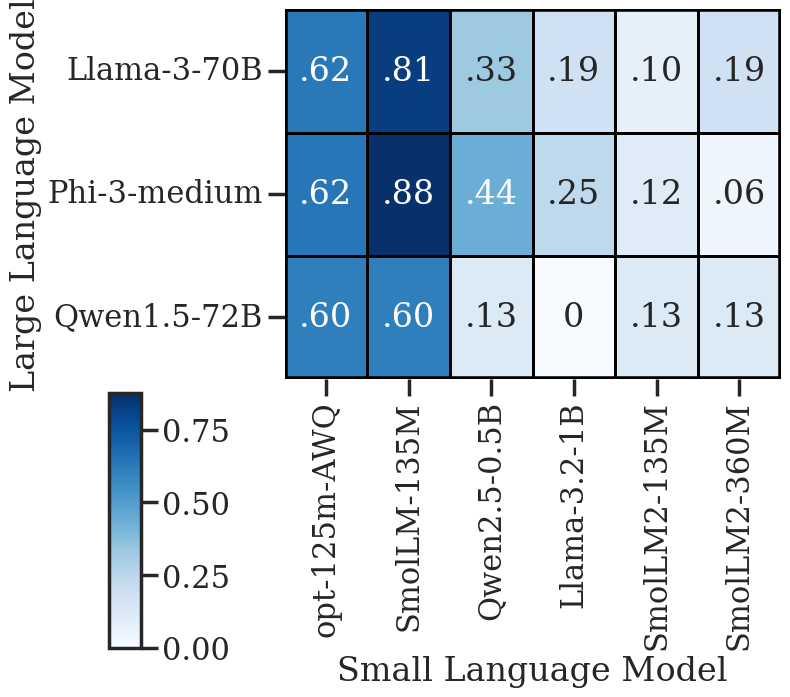

In [9]:
plt.clf()
heatmap(df_gcg_agg, "mean")
plt.savefig(
    figure_dir_path / f"heatmap_gcg.pdf",
    bbox_inches="tight",
    transparent="True",
    pad_inches=0,
)

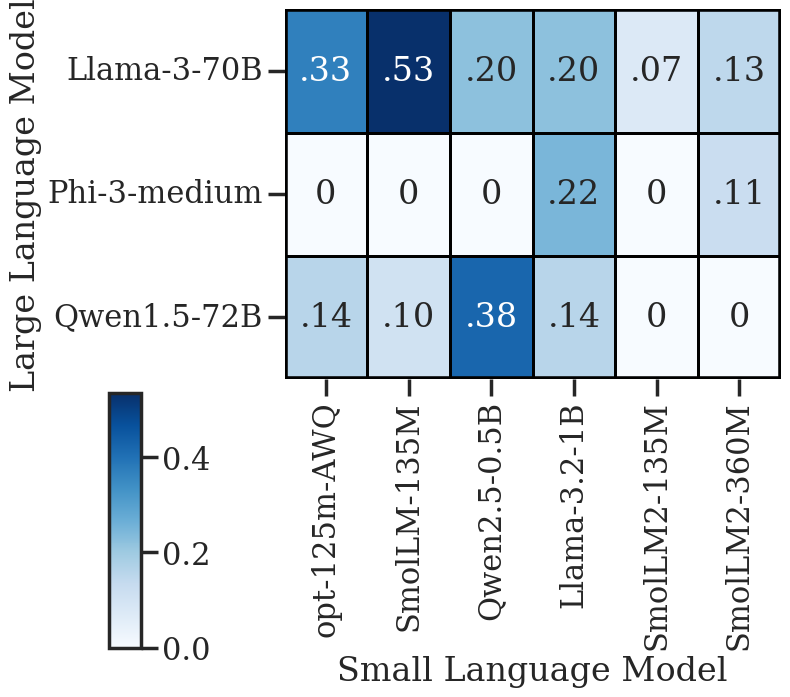

In [10]:
plt.clf()
heatmap(df_autodan_agg, "mean")
plt.savefig(
    figure_dir_path / f"heatmap_autodan.pdf",
    bbox_inches="tight",
    transparent="True",
    pad_inches=0,
)

In [11]:
def agg_intent_index(df):
    v = df.drop(
        columns=[
            "intent_index",
        ]
    )

    return v

df_gcg_agg = agg_intent_index(df_gcg)
df_autodan_agg = agg_intent_index(df_autodan)

/depot/zcelik/data/hongyu/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/depot/zcelik/data/hongyu/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


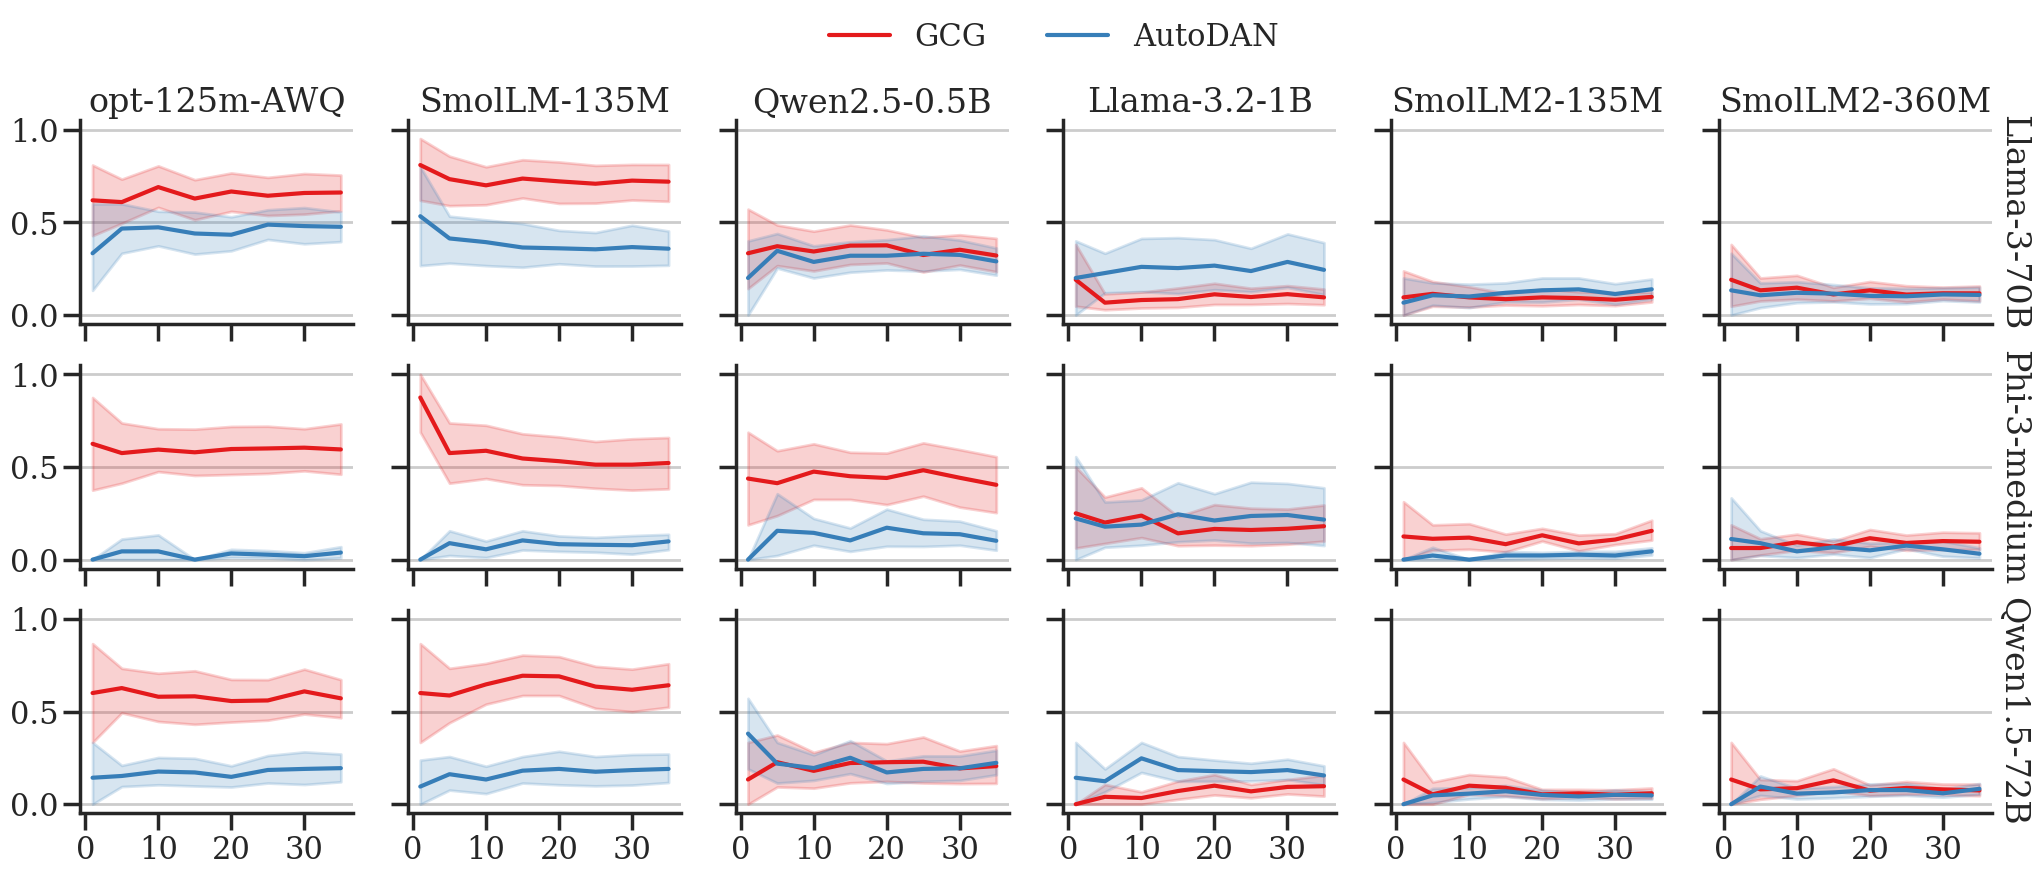

In [12]:
def lineplot(df):
    # assert len(df.columns) == 5

    g = sns.FacetGrid(
        df,
        row="target_model_name",
        col="draft_model_name",
        margin_titles=True,
        row_order=[
            "Llama-3-70B",
            "Phi-3-medium",
            "Qwen1.5-72B",
        ],
        col_order=[
            "opt-125m-AWQ",
            "SmolLM-135M",
            "Qwen2.5-0.5B",
            "Llama-3.2-1B",
            "SmolLM2-135M",
            "SmolLM2-360M",
        ],
        aspect=1.3,
        hue="generation_name",
    )
    g.map(
        sns.lineplot,
        "draft_number",
        "transferability_rate",
        # markers=True,
        # fill=False,
        # linewidth=0.5,
        # inner="quartile",
        # color="black",
        # color="lemonchiffon",
        # color=sns.color_palette("Blues")[0],
    )
    # please add stripplot
    # g.map(
    #     sns.stripplot,
    #     "generation_name",
    #     "transferability_rate",
    #     # color=sns.color_palette("Blues")[3],
    #     # size=5,
    #     alpha=0.2,
    # )

    g.add_legend(title="")

    sns.move_legend(g, "upper center", bbox_to_anchor=(0.5, 1.02), ncol=2)

    g.set_titles(col_template="{col_name}", row_template="{row_name}")
    g.set_xlabels("")
    g.set_ylabels("")

    for ax in g.axes.flat:
        ax.xaxis.set_major_locator(plticker.MultipleLocator(10))
        ax.grid(axis="y")


df_gcg_agg["generation_name"] = "GCG"
df_autodan_agg["generation_name"] = "AutoDAN"
df_agg = pd.concat([df_gcg_agg, df_autodan_agg])
lineplot(df_agg)
# plt.savefig(
#     figure_dir_path / f"lineplot-draft_number.pdf",
#     bbox_inches="tight",
#     transparent="True",
#     pad_inches=0,
# )

/depot/zcelik/data/hongyu/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


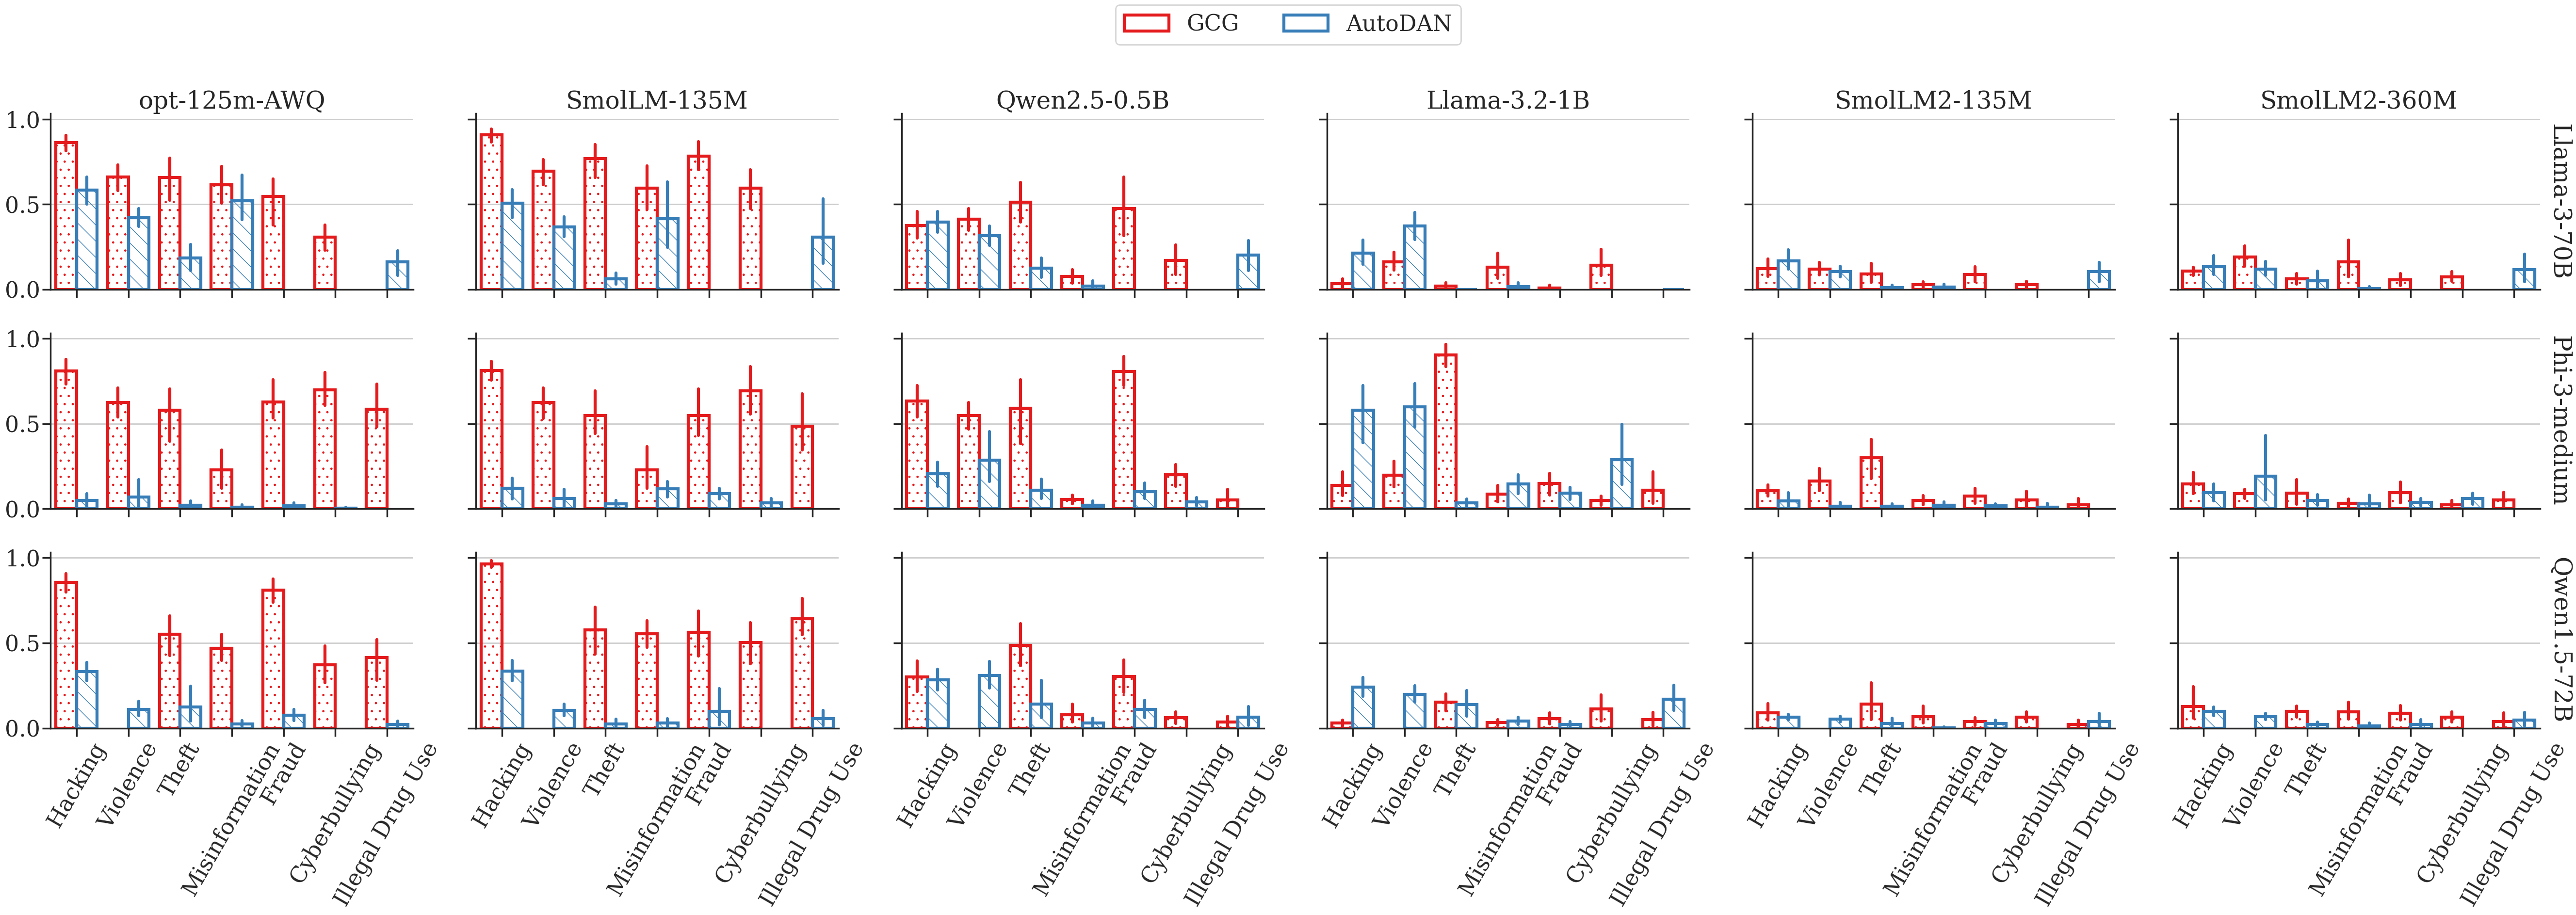

In [16]:
sns.set_context("poster", font_scale=1.5)

def barplot(df):
    g = sns.catplot(
        data=df,
        kind="bar",
        x="category",
        y="transferability_rate",
        hue="generation_name",
        row="target_model_name",
        col="draft_model_name",
        margin_titles=True,
        row_order=[
            "Llama-3-70B",
            "Phi-3-medium",
            "Qwen1.5-72B",
        ],
        col_order=[
            "opt-125m-AWQ",
            "SmolLM-135M",
            "Qwen2.5-0.5B",
            "Llama-3.2-1B",
            "SmolLM2-135M",
            "SmolLM2-360M",
        ],
        aspect=1.5,
        height=6,  # you can adjust this
        legend_out=False,
        fill=False,
        # palette="deep",
    )

    for (
        generation_name,
        target_model_alias,
    ), ax in g.axes_dict.items():
        ax.grid(axis="y")
        hatches = [".", "\\", "//", "+", "|"]
        for bars, hatch in zip(ax.containers, hatches):
            for bar in bars:
                bar.set_hatch(hatch)

    # g.set_xticklabels(rotation=0)
    g.tick_params(axis='x', rotation=60)

    g.set_titles(col_template="{col_name}", row_template="{row_name}")
    g.set_xlabels("")
    g.set_ylabels("")
    g.add_legend(title="")

    g.fig.subplots_adjust(hspace=0.4)
    g.fig.subplots_adjust(wspace=0.1)

    # Adjust legend position
    sns.move_legend(g, "upper center", bbox_to_anchor=(0.5, 1.08), ncol=2)

    plt.tight_layout()


df_gcg_agg["generation_name"] = "GCG"
df_autodan_agg["generation_name"] = "AutoDAN"
df_agg = pd.concat([df_gcg_agg, df_autodan_agg])
barplot(df_agg)
plt.savefig(
    figure_dir_path / f"barplot-category.pdf",
    bbox_inches="tight",
    transparent="True",
    pad_inches=0,
)

# sns.set_context("poster", font_scale=1)

/depot/zcelik/data/hongyu/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/depot/zcelik/data/hongyu/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


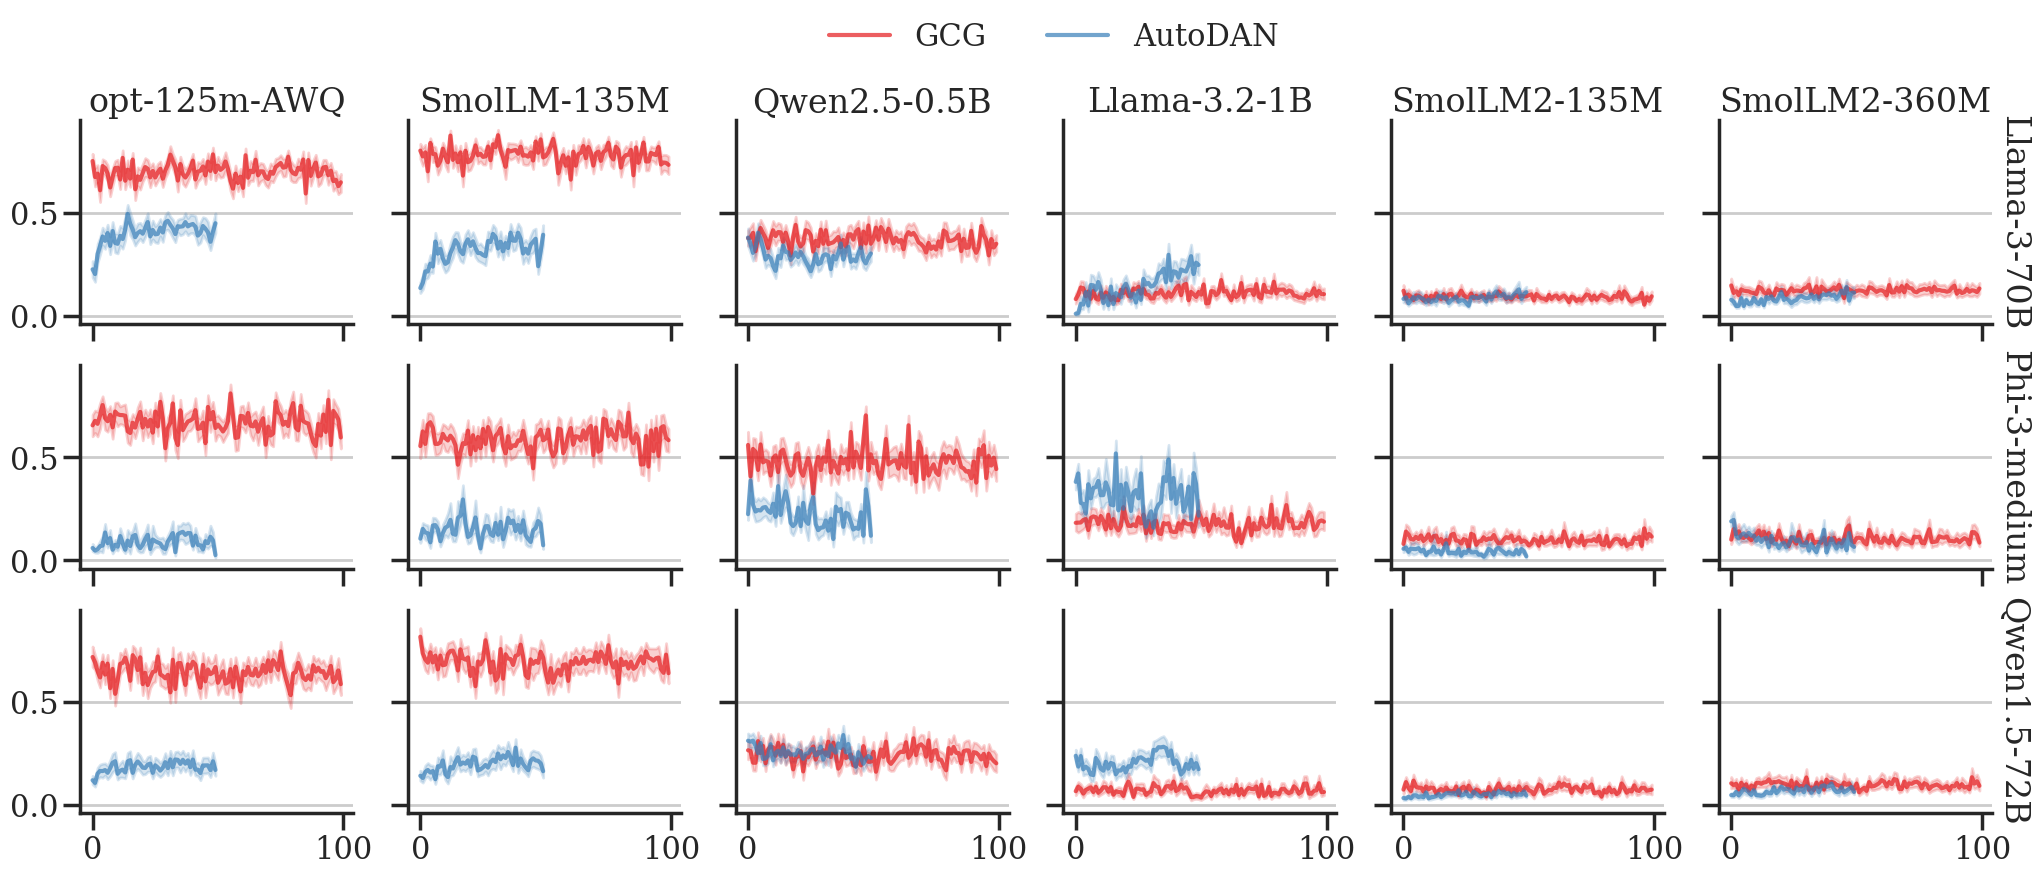

In [17]:
df = original_df

df = df[df["draft_number"] == 1]

assert len(df["dataset_name"].unique()) == 1
assert len(df["draft_number"].unique()) == 1

df = original_df.drop(
    columns=[
        "dataset_name",
        "draft_number",
    ]
)

# df = df[
#     ((df["generation_name"] == "GCG") & (df["attempt_id"] == 99))
#     | ((df["generation_name"] == "AutoDAN") & (df["attempt_id"] == 49))
# ]
# df = df[df["generation_name"] == "AutoDAN"]
sns.set_context("poster", font_scale=1)

g = sns.FacetGrid(
    df,
    row="target_model_name",
    col="draft_model_name",
    margin_titles=True,
    row_order=[
        "Llama-3-70B",
        "Phi-3-medium",
        "Qwen1.5-72B",
    ],
    col_order=[
        "opt-125m-AWQ",
        "SmolLM-135M",
        "Qwen2.5-0.5B",
        "Llama-3.2-1B",
        "SmolLM2-135M",
        "SmolLM2-360M",
    ],
    aspect=1.3,
    hue="generation_name",
    # despine=False,
)
g.map(
    sns.lineplot,
    "attempt_id",
    "transferability_rate",
    # ci="sd",
    alpha=0.7,
)
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_xlabels("")
g.set_ylabels("")

for ax in g.axes.flatten():
    ax.grid(axis='y')

g.add_legend(title="")

sns.move_legend(g, "upper center", bbox_to_anchor=(0.5, 1.02), ncol=2)

plt.savefig(
    figure_dir_path / f"lineplot-attempt_id.pdf",
    bbox_inches="tight",
    transparent="True",
    pad_inches=0,
)

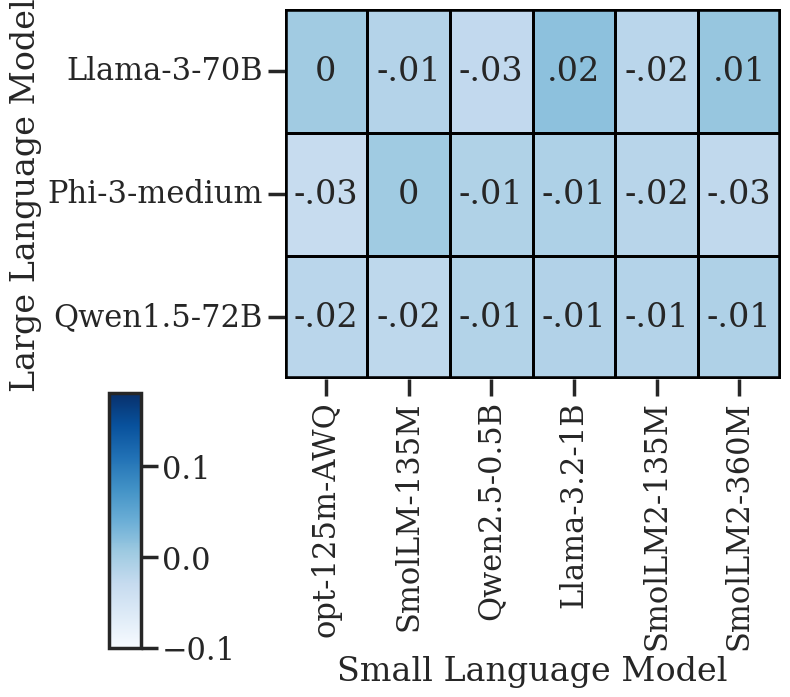

In [18]:
df = original_df

df = df[df["draft_number"] == 1]

assert len(df["dataset_name"].unique()) == 1
assert len(df["draft_number"].unique()) == 1

df = original_df.drop(
    columns=[
        "dataset_name",
        "draft_number",
    ]
)

# for each target_model_name and draft_model_name, calculate the Pearson correlation between the transferability_rate and attempt_id

def pearson_correlation(df):
    pearson_correlation_list = []
    for target_model_name in df["target_model_name"].unique():
        for draft_model_name in df["draft_model_name"].unique():
            df_temp = df[
                (df["target_model_name"] == target_model_name)
                & (df["draft_model_name"] == draft_model_name)
            ]
            pearson_correlation = df_temp["transferability_rate"].corr(df_temp["attempt_id"])
            pearson_correlation_list.append(
                {
                    "target_model_name": target_model_name,
                    "draft_model_name": draft_model_name,
                    "pearson_correlation": pearson_correlation,
                }
            )
    return pd.DataFrame(pearson_correlation_list)

df_gcg = df[df["generation_name"] == "GCG"]
df_autodan = df[df["generation_name"] == "AutoDAN"]

pearson_correlation_df_gcg = pearson_correlation(df_gcg)
pearson_correlation_df_autodan = pearson_correlation(df_autodan)

plt.clf()
heatmap(
    pearson_correlation_df_gcg,
    "pearson_correlation",
    vmin=-0.1,
    vmax=0.18,
)
plt.savefig(
    figure_dir_path / f"heatmap_pearson_correlation_gcg.pdf",
    bbox_inches="tight",
    transparent="True",
    pad_inches=0,
)

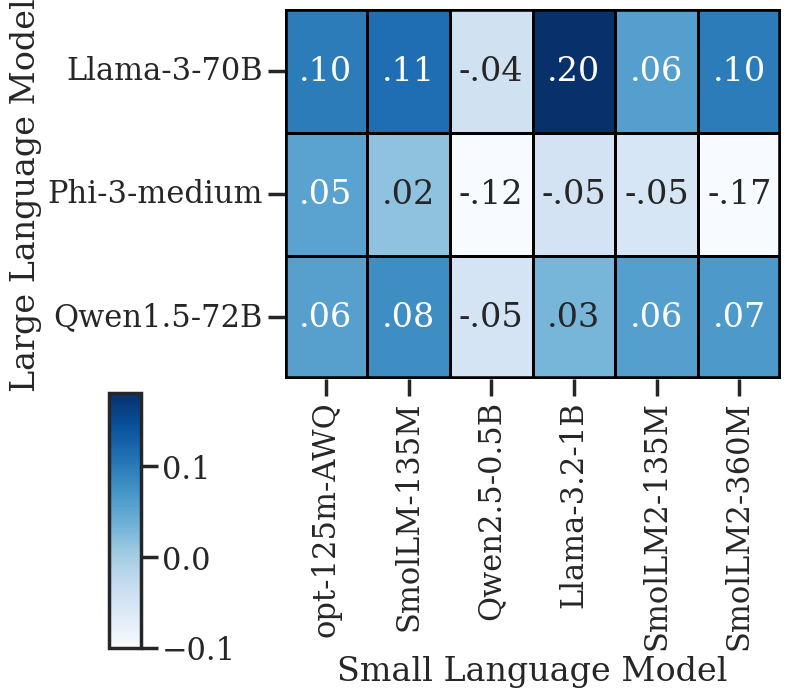

In [19]:
plt.clf()
heatmap(
    pearson_correlation_df_autodan,
    "pearson_correlation",
    vmin=-0.1,
    vmax=0.18,
)
plt.savefig(
    figure_dir_path / f"heatmap_pearson_correlation_autodan.pdf",
    bbox_inches="tight",
    transparent="True",
    pad_inches=0,
)